# Train Commutative CNN

This notebook intentionally keeps orchestration thin. Split preparation, fitting, reporting, plotting, and persistence are delegated to shared utilities in `src.ml`.


In [1]:
%load_ext autoreload
%autoreload 2

from dataclasses import asdict
from pathlib import Path

import pandas as pd

from src.ml import (
    LossWeightConfig,
    OptimizationConfig,
    display_experiment_summary,
    display_holdout_evaluation,
    fit_estimator_on_experiment,
    persist_experiment_artifacts,
    plot_holdout_branch_embedding_projections,
    plot_training_history,
    prepare_multitask_experiment_data,
)
from src.dataset_config import load_current_dataset_artifact_path
from src.tensor_utils import build_tensor_embedding_2d, load_labeled_tensor_dataset, plot_tensor_embedding_2d

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)


In [2]:
from src.ml import CommutativeCNNClassifier, CommutativeCNNConfig


In [3]:
# User inputs

dataset_artifact_path = load_current_dataset_artifact_path()
print(dataset_artifact_path.name)
experiment_output_dir = Path("artifacts/nb7_commutative_cnn")
persist_artifacts = True

holdout_fraction = 0.25
validation_fraction_within_train = 0.20
train_num_random_rotations = 6
rotation_range_degrees = 12.0

model_config = CommutativeCNNConfig(
    spatial_conv_channels=(6, 8),
    spatial_kernel_size_z=(1, 1),
    spatial_kernel_size_xy=(5, 3),
    spatial_stride_z=(1, 1),
    spatial_stride_xy=(1, 1),
    spatial_pool_kernel_z=(1, 1),
    spatial_pool_kernel_xy=(2, 2),
    spatial_pool_stride_z=(1, 1),
    spatial_pool_stride_xy=(2, 2),
    temporal_st_channels=(12,),
    temporal_st_kernel_sizes=(3,),
    temporal_ts_channels=(8,),
    temporal_ts_kernel_sizes=(5,),
    spatial_agg_channels=(12,),
    spatial_agg_kernel_size_z=(3,),
    spatial_agg_kernel_size_xy=(3,),
    spatial_agg_stride_z=(1,),
    spatial_agg_stride_xy=(1,),
    spatial_agg_pool_kernel_z=(1,),
    spatial_agg_pool_kernel_xy=(2,),
    spatial_agg_pool_stride_z=(1,),
    spatial_agg_pool_stride_xy=(2,),
    patch_size_z=1,
    patch_size_xy=16,
    embedding_dim=8,
    num_prototypes=8,
    dropout=0.5,
)
optimization_config = OptimizationConfig(
    batch_size=8,
    epochs=100,
    learning_rate=2e-4,
    weight_decay=3e-3,
    early_stopping_patience=4,
    early_stopping_min_delta=0.0,
    scheduler_patience=1,
    scheduler_factor=0.5,
    scheduler_min_lr=1e-6,
    validation_split=0.0,
    random_state=0,
    standardize=True,
    device=None,
    verbose=True,
)
loss_weight_config = LossWeightConfig(
    action_weight=1.0,
    compound_weight=0.05,
    concentration_weight=0.05,
    consistency_weight=0.05,
    feature_weight=0.0,
    prototype_temperature=0.1,
)


moa_GA_An_NM_Ac_AC_In_mA_Ag_c2_mca3_mtc16_t20_z5_y64_x64.pt


In [4]:
dataset = load_labeled_tensor_dataset(dataset_artifact_path)


In [5]:
experiment = prepare_multitask_experiment_data(
    dataset,
    holdout_fraction=holdout_fraction,
    validation_fraction_within_train=validation_fraction_within_train,
    train_num_random_rotations=train_num_random_rotations,
    rotation_range_degrees=rotation_range_degrees,
    random_state=optimization_config.random_state,
)


In [6]:
display_experiment_summary(experiment)


,split,n_samples
0,train_augmented,1169
1,train_base,167
2,val,42
3,holdout,70


,mechanism_of_action,compound,concentration_band,n_samples
0,GABAAR_Antagonist,Gabazine,high,49
1,GABAAR_Antagonist,Bemegride,control,49
2,AChE_Inhibitor_Reversible,Galantamine,high,42
3,GABAAR_Antagonist,Gabazine,control,42
4,mAChR_Agonist_NonSelective,Bethanechol,high,42
5,mAChR_Agonist_NonSelective,Bethanechol,mid,42
6,NMDAR_Activation,Cis-ACPD,control,42
7,AChE_Inhibitor_Reversible,Donepezil,control,35
8,NMDAR_Activation,N-methyl-D-aspartate,high,35
9,AChE_Inhibitor_Reversible,Galantamine,control,35


In [7]:
model = CommutativeCNNClassifier(
    model_config=model_config,
    optimization_config=optimization_config,
    loss_weight_config=loss_weight_config,
)


In [8]:
fit_estimator_on_experiment(model, experiment)


cols:
    ep=epoch
    lr=learning_rate
    eta=estimated_time_remaining
    trL=train_loss
    trA=train_action_loss
    trCC=train_commutative_consistency_loss
    trFA=train_feature_alignment_loss
    trCo=train_compound_loss
    trCn=train_concentration_loss
    vaL=val_loss
    vaA=val_action_loss
    vaCC=val_commutative_consistency_loss
    vaFA=val_feature_alignment_loss
    vaCo=val_compound_loss
    vaCn=val_concentration_loss
     ep       lr       eta |      trL      trA     trCC     trFA     trCo     trCn |      vaL      vaA     vaCC     vaFA     vaCo     vaCn
001/100 2.00e-04     48:36 |   1.9795   1.5789   4.3785   0.5399   2.5221   1.1118 |   1.8758   1.5566   2.7522   0.2422   2.5270   1.1057
002/100 2.00e-04     44:59 |   1.8840   1.5426   3.2106   0.3780   2.5104   1.1075 |   1.8441   1.5465   2.3293   0.2146   2.5136   1.1093
003/100 2.00e-04     43:58 |   1.8494   1.5259   2.8863   0.3303   2.4886   1.0961 |   1.8059   1.5304   1.9087   0.1352   2.4914   1.1098
004

,spatial_conv_channels,"(6, ...)"
,spatial_kernel_size_z,"(1, ...)"
,spatial_kernel_size_xy,"(5, ...)"
,spatial_stride_z,"(1, ...)"
,spatial_stride_xy,"(1, ...)"
,spatial_pool_kernel_z,"(1, ...)"
,spatial_pool_kernel_xy,"(2, ...)"
,spatial_pool_stride_z,"(1, ...)"
,spatial_pool_stride_xy,"(2, ...)"
,temporal_st_channels,"(12,)"
,temporal_st_kernel_sizes,"(3,)"


Failed to reload module 'src.ml' from file '/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/ZebraFish/src/ml.py'
Traceback (most recent call last):
  File "/home/fabrizio/.venvs/py313/lib/python3.13/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/fabrizio/.venvs/py313/lib/python3.13/site-packages/IPython/extensions/autoreload.py", line 584, in superreload
    module = reload(module)
  File "/usr/lib/python3.13/importlib/__init__.py", line 129, in reload
    _bootstrap._exec(spec, module)
    ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 1026, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/ZebraFish/src/ml.py", line 37, 

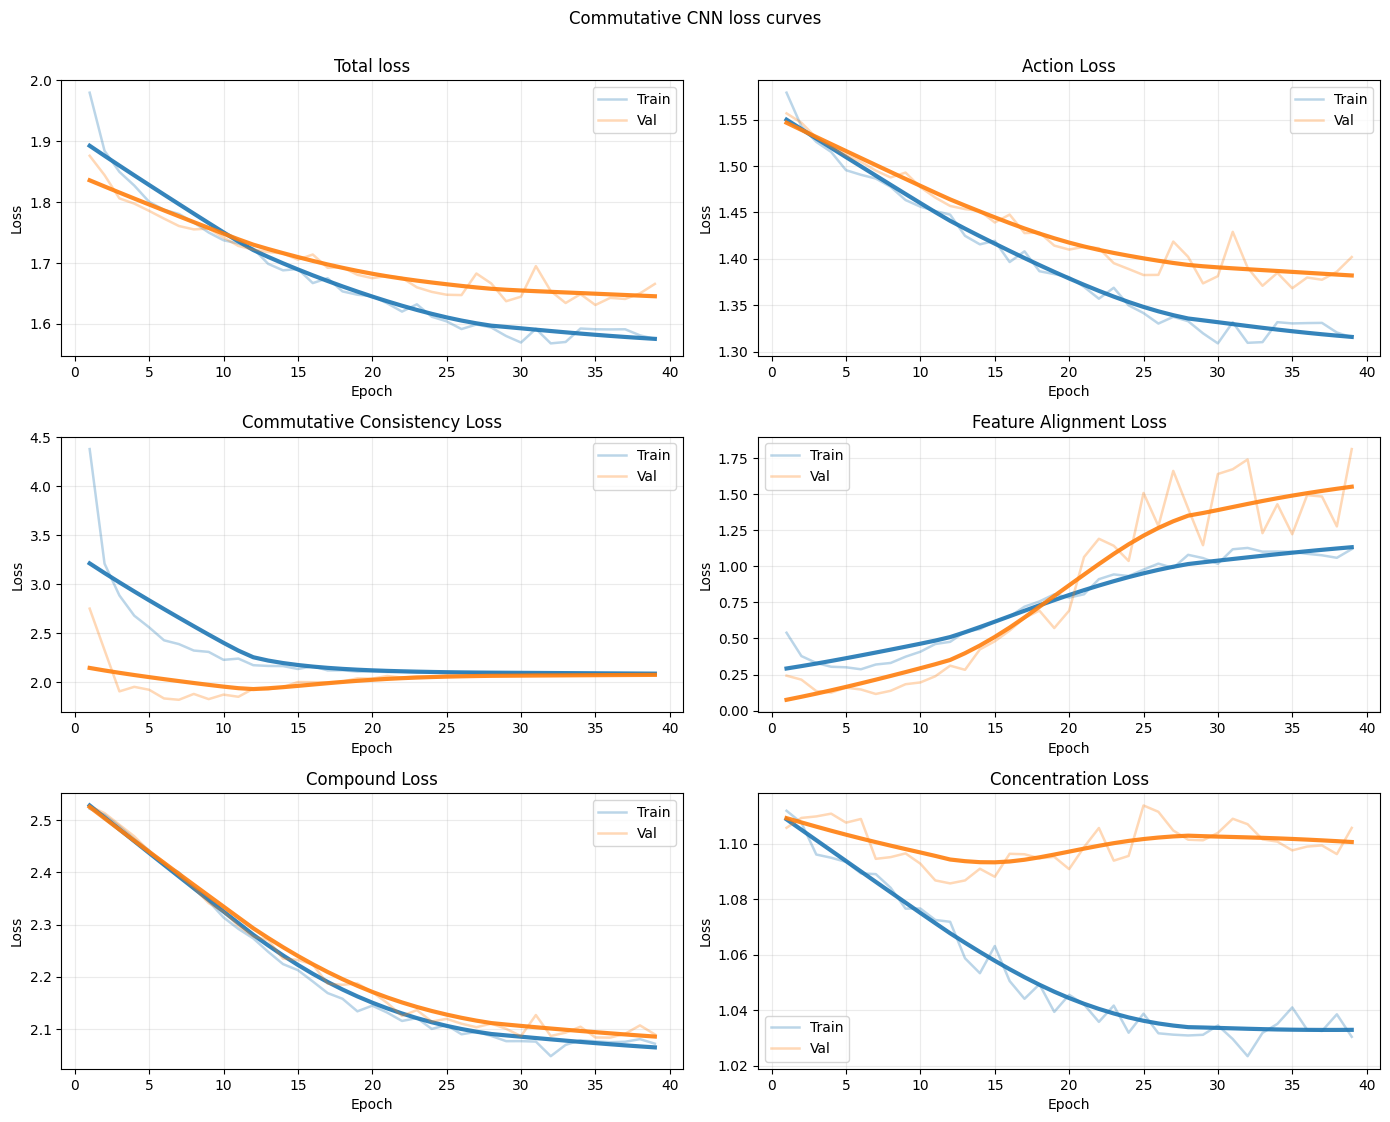

In [9]:
plot_training_history(model, title="Commutative CNN loss curves", loess_frac=0.6);



## Holdout report: action


,precision,recall,f1-score,support
class,,,,
Water,0.400000,0.916667,0.556962,24.0
GABAAR_Antagonist,0.666667,0.333333,0.444444,12.0
NMDAR_Activation,0.888889,0.800000,0.842105,10.0
AChE_Inhibitor_Reversible,0.000000,0.000000,0.000000,12.0
mAChR_Agonist_NonSelective,0.000000,0.000000,0.000000,12.0


,value
accuracy,0.485714
macro_precision,0.391111
macro_recall,0.410000
macro_f1,0.368702
weighted_precision,0.378413
weighted_recall,0.485714
weighted_f1,0.387450
n_samples,70.000000
roc_auc_ovr_macro,0.736118
average_precision_macro,0.501652


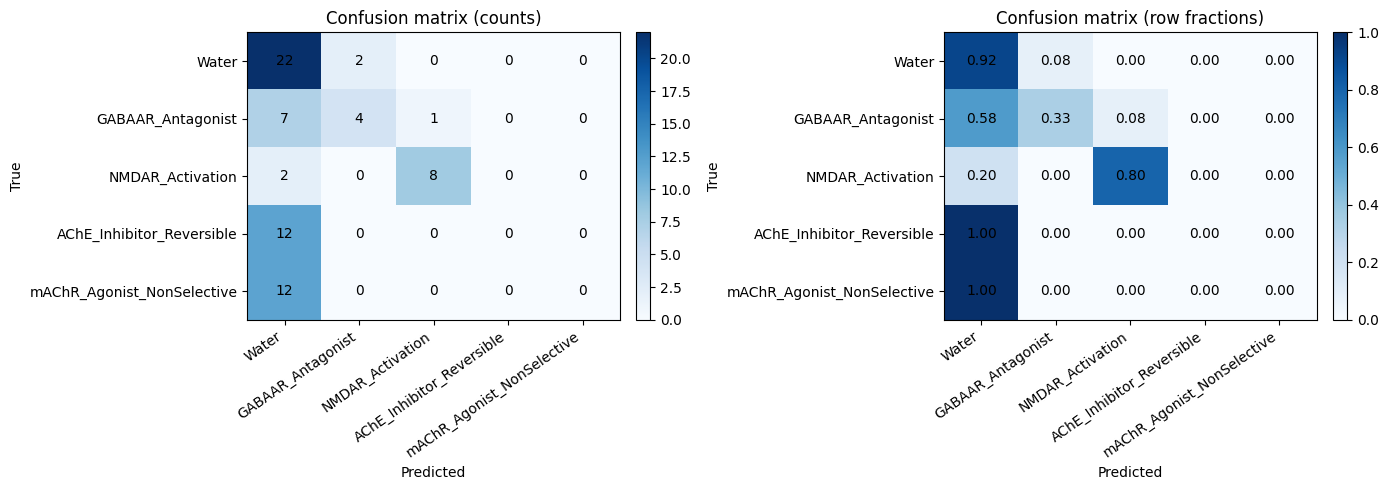


## Holdout report: compound


,precision,recall,f1-score,support
class,,,,
Control,0.396552,0.958333,0.560976,24.0
Bemegride,0.000000,0.000000,0.000000,6.0
Bicuculline,0.500000,0.333333,0.400000,3.0
Gabazine,0.000000,0.000000,0.000000,3.0
(RS)-(Tetrazol-5-yl)glycine,0.375000,1.000000,0.545455,3.0
Cis-ACPD,0.000000,0.000000,0.000000,3.0
N-methyl-D-aspartate,1.000000,0.500000,0.666667,4.0
Donepezil,0.000000,0.000000,0.000000,4.0
Galantamine,0.000000,0.000000,0.000000,4.0


,value
accuracy,0.414286
macro_precision,0.174735
macro_recall,0.214744
macro_f1,0.167161
weighted_precision,0.230603
weighted_recall,0.414286
weighted_f1,0.270949
n_samples,70.000000
roc_auc_ovr_macro,0.719613
average_precision_macro,0.245956


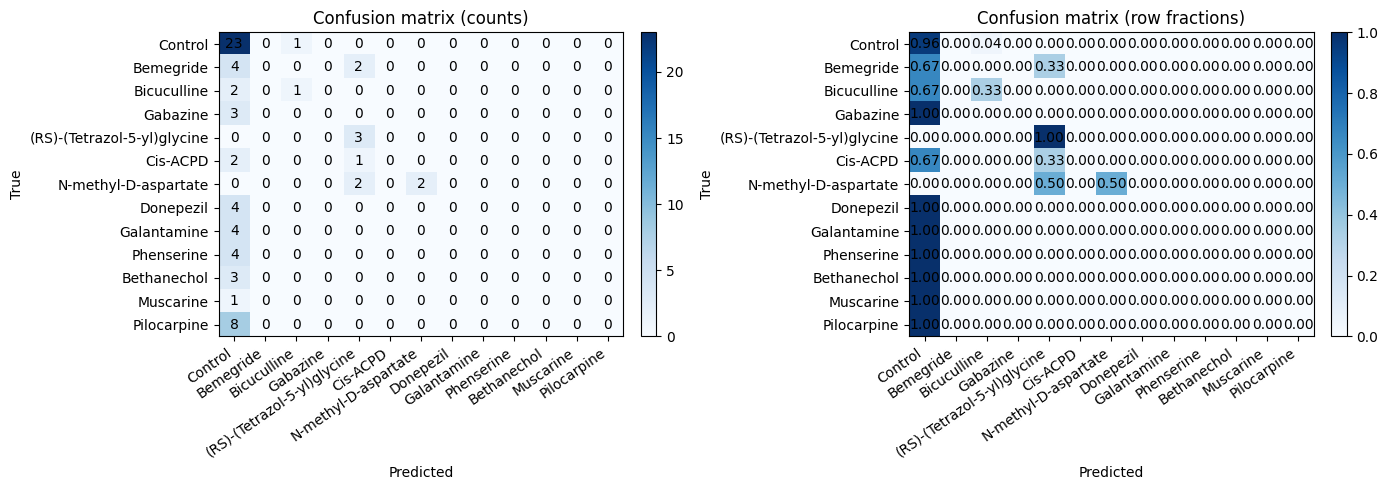


## Holdout report: concentration


,precision,recall,f1-score,support
class,,,,
control,0.396226,0.875,0.545455,24.0
high,0.529412,0.360,0.428571,25.0
mid,0.000000,0.000,0.000000,21.0


,value
accuracy,0.428571
macro_precision,0.308546
macro_recall,0.411667
macro_f1,0.324675
weighted_precision,0.324925
weighted_recall,0.428571
weighted_f1,0.340074
n_samples,70.000000
roc_auc_ovr_macro,0.567945
average_precision_macro,0.413752


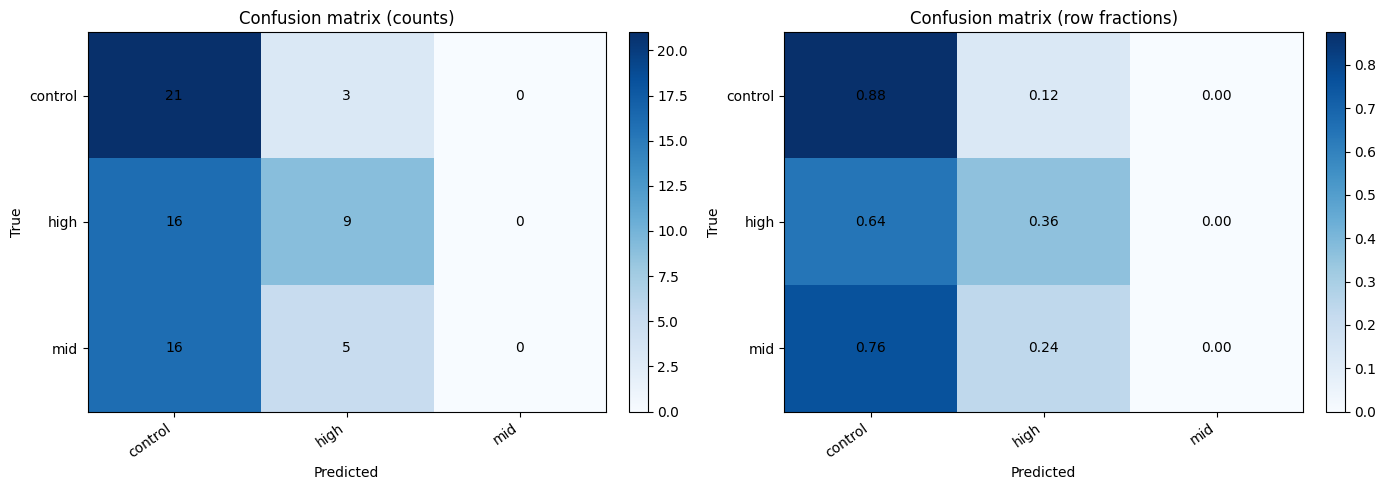

In [10]:
holdout_evaluation = display_holdout_evaluation(model, experiment)


/home/fabrizio/.venvs/py313/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(<Figure size 1550x1050 with 1 Axes>,
 <Axes: title={'center': 'Holdout embedding projection by action'}, xlabel='Component 1', ylabel='Component 2'>)

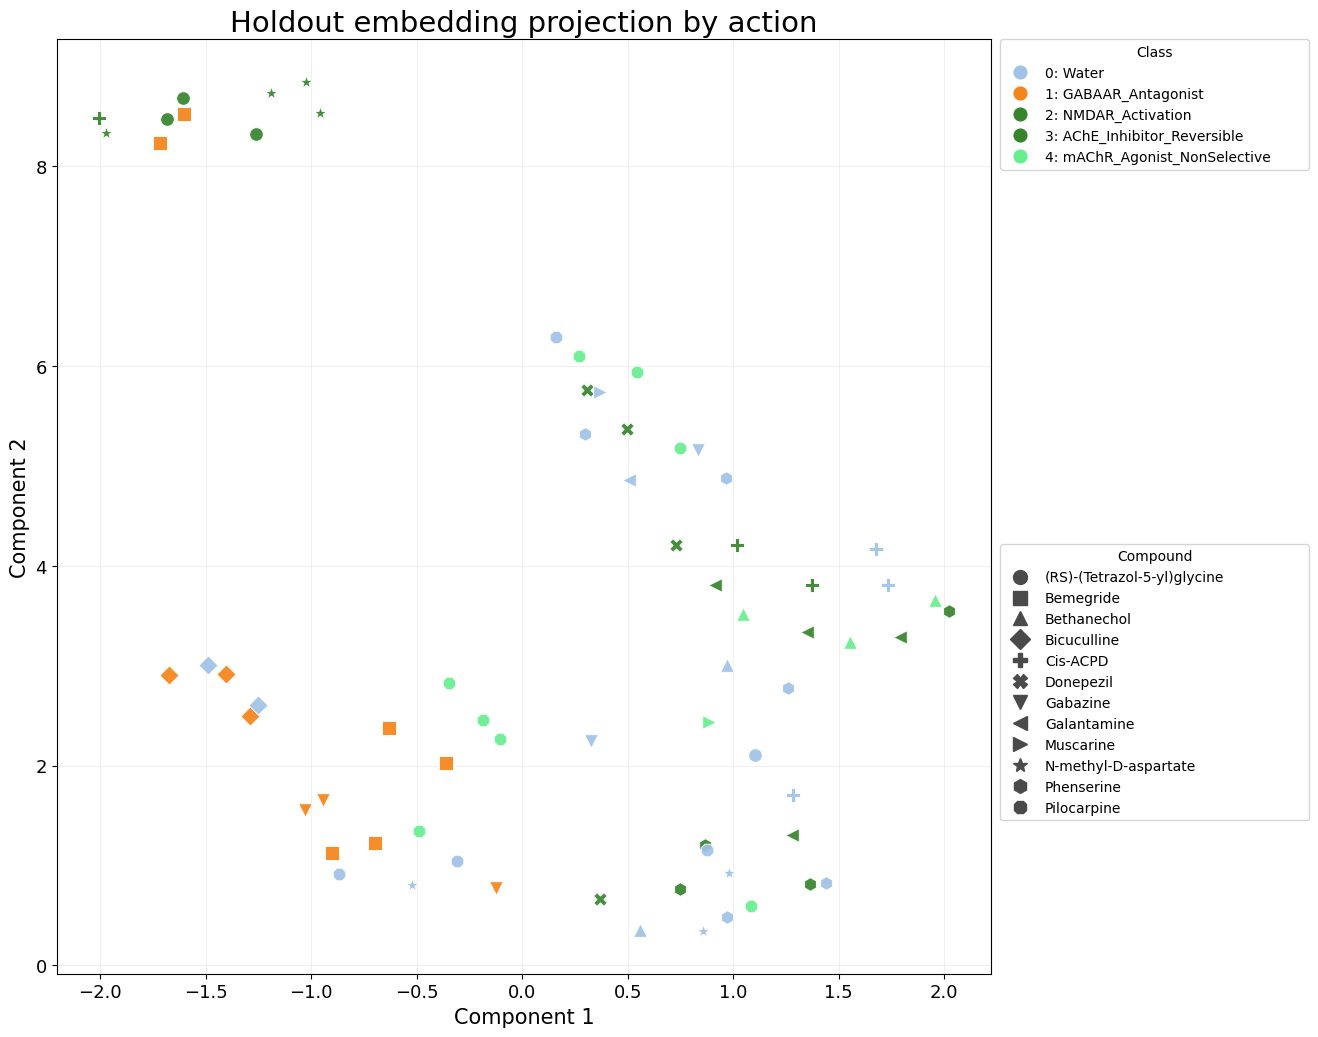

In [11]:
holdout_embedding_projection = build_tensor_embedding_2d(
    model.transform(experiment.splits.X_holdout),
    experiment.y_true_holdout["action"],
    label_map=experiment.label_maps["action"],
    metadata=experiment.splits.metadata_holdout,
    method="umap",
    random_state=optimization_config.random_state,
)
plot_tensor_embedding_2d(
    holdout_embedding_projection,
    title="Holdout embedding projection by action",
    marker_column="compound",
)


In [12]:
run_config = {
    "dataset_artifact_path": dataset_artifact_path,
    "holdout_fraction": holdout_fraction,
    "validation_fraction_within_train": validation_fraction_within_train,
    "train_num_random_rotations": train_num_random_rotations,
    "rotation_range_degrees": rotation_range_degrees,
    "model_config": asdict(model_config),
    "optimization_config": asdict(optimization_config),
    "loss_weight_config": asdict(loss_weight_config),
}


In [13]:
if persist_artifacts:
    experiment_artifacts = persist_experiment_artifacts(
        output_dir=experiment_output_dir,
        estimator=model,
        reports=holdout_evaluation.reports,
        config=run_config,
    )
